# Lahchen Maps — India Child Stunting Atlas
**NFHS-5 (2019–21)** · six narrative figures in the Lahchen Maps house style.

This notebook keeps the original data-cleaning pipeline **unchanged** (Part 1), adds a
single per-state aggregation block (Part 2), then builds the six figures (Part 3).

> Paths point to the local files used during cleaning. Adjust the two paths in
> Part 1 if your files live elsewhere. Nothing else needs editing.

## Part 1 — Data cleaning (unchanged)

In [15]:
import pandas as pd
import numpy as np

# --- load KR microdata ---
file_path = r"C:\Users\91981\Downloads\IAKR7EDT\IAKR7EFL.DTA"
df = pd.read_stata(file_path, convert_categoricals=False)
print("KR shape:", df.shape)

KR shape: (232920, 1644)


In [16]:
# --- clean height-for-age z-score and build stunting flag ---
df["hw70_clean"] = df["hw70"]
df.loc[df["hw70_clean"] >= 9996, "hw70_clean"] = np.nan

df["stunted"] = (df["hw70_clean"] < -200).astype(int)
df["weight"]  = df["v005"] / 1000000

valid = df[df["hw70_clean"].notna()].copy()

nat = np.average(valid["stunted"], weights=valid["weight"])
print("National stunting (weighted):", round(100*nat, 1), "%")

C:\Users\91981\AppData\Local\Temp\ipykernel_37316\882794946.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hw70_clean"] = df["hw70"]
C:\Users\91981\AppData\Local\Temp\ipykernel_37316\882794946.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["stunted"] = (df["hw70_clean"] < -200).astype(int)
C:\Users\91981\AppData\Local\Temp\ipykernel_37316\882794946.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

National stunting (weighted): 35.5 %


In [17]:
# --- state code -> name map (Census/NFHS codes) ---
state_map = {
 1:'jammu & kashmir',2:'himachal pradesh',3:'punjab',4:'chandigarh',5:'uttarakhand',
 6:'haryana',7:'nct of delhi',8:'rajasthan',9:'uttar pradesh',10:'bihar',11:'sikkim',
 12:'arunachal pradesh',13:'nagaland',14:'manipur',15:'mizoram',16:'tripura',
 17:'meghalaya',18:'assam',19:'west bengal',20:'jharkhand',21:'odisha',22:'chhattisgarh',
 23:'madhya pradesh',24:'gujarat',25:'dadra & nagar haveli and daman & diu',
 27:'maharashtra',28:'andhra pradesh',29:'karnataka',30:'goa',31:'lakshadweep',
 32:'kerala',33:'tamil nadu',34:'puducherry',35:'andaman & nicobar islands',
 36:'telangana',37:'ladakh'
}

## Part 2 — Per-state aggregation (new)\nOne weighted pass produces every variable the six figures need.

In [18]:
# --- weighted per-state aggregation: overall, poor, rich, gap, burden ---
def wmean(d, col="stunted"):
    return np.average(d[col], weights=d["weight"]) if len(d) else np.nan

rows = []
for code_ in sorted(valid["v024"].unique()):
    s = valid[valid["v024"] == code_]
    poor = s[s["v190"] == 1]
    rich = s[s["v190"] == 5]

    overall = wmean(s)
    pr = wmean(poor) if len(poor) else np.nan
    rr = wmean(rich) if len(rich) else np.nan

    # absolute burden proxy: weighted count of stunted children in the survey,
    # i.e. sum of survey weights among stunted kids (population-representative scale)
    burden = (s["stunted"] * s["weight"]).sum()

    rows.append({
        "state_code": code_,
        "state": state_map.get(code_),
        "stunting_pct": 100*overall,
        "poor_stunting_pct": 100*pr if pr==pr else np.nan,
        "rich_stunting_pct": 100*rr if rr==rr else np.nan,
        "gap_pp": 100*(pr-rr) if (pr==pr and rr==rr) else np.nan,
        "burden_weighted": burden,
        "n": len(s),
    })

state_stats = pd.DataFrame(rows)
state_stats.sort_values("stunting_pct", ascending=False).head(10)

,state_code,state,stunting_pct,poor_stunting_pct,rich_stunting_pct,gap_pp,burden_weighted,n
16,17,meghalaya,46.558283,51.465419,7.389775,44.075644,368.426212,6133
9,10,bihar,42.946369,49.391897,20.244690,29.147207,11320.931894,18293
19,20,jharkhand,39.637475,46.559768,17.379131,29.180637,2433.570448,8897
8,9,uttar pradesh,39.581511,49.938368,24.770767,25.167601,15415.355893,30828
24,25,dadra & nagar haveli and daman & diu,39.366240,50.984319,30.206630,20.777689,31.263434,710
23,24,gujarat,39.039771,50.721908,25.445081,25.276827,3410.132494,8878
22,23,madhya pradesh,35.582637,42.404661,21.784624,20.620038,4188.340808,13957
25,27,maharashtra,35.436685,52.855756,28.399412,24.456343,5696.878659,8393
27,29,karnataka,35.396403,49.398489,24.796301,24.602187,3022.207389,7214
17,18,assam,35.299508,40.508977,20.808631,19.700346,1871.481080,9661


### Geometry merge\nLoads the India GeoJSON and attaches every per-state statistic, reusing the name crosswalk.

In [19]:
import geopandas as gpd

# --- load geometry ---
states = gpd.read_file(r"C:\Users\91981\Desktop\Stunting folder\india.json")
states["name_clean"] = states["name"].str.lower().str.strip()
# fix the one accented name so it matches
states["name_clean"] = states["name_clean"].replace({
    "dādra and nagar haveli and damān and diu": "dadra & nagar haveli and daman & diu"
})

# --- align stat names to geometry names (same crosswalk as cleaning) ---
state_stats["state_clean"] = (
    state_stats["state"].str.lower().str.strip().replace({
        "andaman & nicobar islands": "andaman and nicobar",
        "nct of delhi": "delhi",
        "jammu & kashmir": "jammu and kashmir",
        "odisha": "orissa",
        "uttarakhand": "uttaranchal",
        "dadra & nagar haveli and daman & diu": "dadra & nagar haveli and daman & diu",
    })
)

gdf = states.merge(state_stats, left_on="name_clean", right_on="state_clean", how="left")
print("unmatched stat rows:", set(state_stats["state_clean"]) - set(states["name_clean"]))
gdf[["name","stunting_pct","gap_pp"]].head()

unmatched stat rows: set()


,name,stunting_pct,gap_pp
0,Andaman and Nicobar,22.519004,22.606181
1,Telangana,33.036126,23.075731
2,Andhra Pradesh,31.092249,27.636683
3,Arunachal Pradesh,27.988888,16.973646
4,Assam,35.299508,19.700346


In [20]:
# --- per-capita income (Figure 0) ---
income_data = {
    "state": ["andhra pradesh","arunachal pradesh","assam","bihar","chhattisgarh","goa",
        "gujarat","haryana","himachal pradesh","jharkhand","karnataka","kerala",
        "madhya pradesh","maharashtra","manipur","meghalaya","mizoram","nagaland","odisha",
        "punjab","rajasthan","sikkim","tamil nadu","telangana","tripura","uttar pradesh",
        "uttarakhand","west bengal","andaman & nicobar islands","chandigarh","delhi",
        "jammu & kashmir","puducherry"],
    "income_pc": [163746,190212,90482,43605,104788,431351,212821,229065,183333,71071,
        221310,194322,103654,183704,79797,84638,187838,126452,102166,149193,115122,
        412754,212174,225687,119789,61374,184002,106510,197275,291194,331112,102803,203178]
}
income = pd.DataFrame(income_data)
income["state_clean"] = income["state"].replace({
    "andaman & nicobar islands":"andaman and nicobar","delhi":"delhi",
    "jammu & kashmir":"jammu and kashmir","odisha":"orissa","uttarakhand":"uttaranchal",
})
gdf = gdf.merge(income[["state_clean","income_pc"]], on="state_clean", how="left")
gdf[["name","income_pc"]].sort_values("income_pc", ascending=False).head(8)

,name,income_pc
10,Goa,431351.0
27,Sikkim,412754.0
9,Delhi,331112.0
6,Chandigarh,291194.0
12,Haryana,229065.0
1,Telangana,225687.0
15,Karnataka,221310.0
11,Gujarat,212821.0


## Part 3 — The six figures (Lahchen Maps aesthetic)

Shared house style: warm ledger paper, Fraunces-style serif titles via DejaVu Serif,
oxblood→paper sequential ramp, hairline white state borders, mono footnotes, and
hand-placed callouts on the states that carry the story.

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib import patheffects as pe
import numpy as np

# ---- Lahchen Maps palette ----
PAPER   = "#f2ede1"
PANEL   = "#e9e2d1"
INK     = "#1b2a3a"
INKSOFT = "#41566b"
RULE    = "#c9bfa8"
OXBLOOD = "#8c2f24"
PLOT    = "#2d4a63"
GREEN   = "#4f7a5e"

ramp      = LinearSegmentedColormap.from_list("lahchen",      ["#f6efe1","#e9cdac","#d98c63","#b9512f","#8c2f24"])
ramp_cool = LinearSegmentedColormap.from_list("lahchen_cool", ["#f3efe6","#bcd0d6","#7da3b4","#4a7187","#2d4a63"])

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "text.color": INK, "axes.edgecolor": RULE,
})

HALO = [pe.withStroke(linewidth=3, foreground=PAPER)]

def lahchen_base(figsize=(9.5, 13)):
    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor(PAPER)
    # map lives in a fixed UPPER band so legend + table never overlap it
    ax = fig.add_axes([0.04, 0.46, 0.92, 0.40])   # [left, bottom, width, height]
    ax.set_facecolor(PAPER); ax.axis("off")
    return fig, ax

def title_block(fig, eyebrow, title, subtitle):
    fig.text(0.06, 0.975, eyebrow, family="monospace", fontsize=10, color=OXBLOOD)
    fig.text(0.06, 0.948, title, fontsize=25, fontweight="bold", color=INK)
    fig.text(0.06, 0.922, subtitle, fontsize=12, color=INKSOFT, style="italic")

def takeaway(fig, text):
    fig.text(0.06, 0.892, text, fontsize=12.5, color=INK, fontweight="bold", wrap=True)

def footnote(fig, text):
    fig.text(0.06, 0.018, text, family="monospace", fontsize=8.2, color=INKSOFT)

def callout(ax, gdf, name, label, dx, dy, color=INK):
    row = gdf[gdf["name"] == name]
    if row.empty or row.geometry.iloc[0] is None: return
    c = row.geometry.iloc[0].centroid
    ax.annotate(label, xy=(c.x, c.y), xytext=(c.x+dx, c.y+dy),
        fontsize=10.5, color=color, family="serif", weight="bold",
        ha="left", va="center", path_effects=HALO,
        arrowprops=dict(arrowstyle="-", color=color, lw=1,
                        connectionstyle="arc3,rad=0.15"))

def draw_choropleth(ax, gdf, column, cmap, vmin=None, vmax=None):
    gdf.plot(column=column, cmap=cmap, vmin=vmin, vmax=vmax,
             linewidth=0.5, edgecolor="white", ax=ax,
             missing_kwds={"color":"#dcd4c2","edgecolor":"white","linewidth":0.5})

def descriptive_legend(fig, cmap, vmin, vmax, unit, low_label, high_label,
                       note=None, n_ticks=5, integer=False):
    """Horizontal legend that says what colour means, with well-spaced ticks."""
    cax = fig.add_axes([0.36, 0.40, 0.34, 0.018])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap,
                                   norm=Normalize(vmin=vmin, vmax=vmax),
                                   orientation="horizontal")
    cb.outline.set_edgecolor(RULE)
    # SPACED-OUT ticks: choose a small number of round values, no crowding
    loc = MaxNLocator(nbins=n_ticks, integer=integer, prune="both")
    ticks = loc.tick_values(vmin, vmax)
    ticks = [t for t in ticks if vmin <= t <= vmax]
    cb.set_ticks(ticks)
    cb.ax.tick_params(labelsize=8, color=RULE, labelcolor=INKSOFT, length=4, pad=3)
    cb.ax.set_xticklabels([f"{t:,.0f}" for t in ticks])
    # plain-language end labels, pulled clear of the bar ends
    fig.text(0.345, 0.432, low_label,  fontsize=9.5, color=INKSOFT, ha="right", style="italic")
    fig.text(0.715, 0.432, high_label, fontsize=9.5, color=INKSOFT, ha="left",  style="italic")
    fig.text(0.53, 0.358, unit, fontsize=8.8, color=INKSOFT, ha="center", family="monospace")
    if note:
        fig.text(0.53, 0.452, note, fontsize=9.5, color=INK, ha="center", style="italic")

# --- state abbreviations (used both on the map and in the table) ---
STATE_ABBR = {
 "andhra pradesh":"AP","arunachal pradesh":"AR","assam":"AS","bihar":"BR",
 "chhattisgarh":"CG","goa":"GA","gujarat":"GJ","haryana":"HR","himachal pradesh":"HP",
 "jharkhand":"JH","karnataka":"KA","kerala":"KL","madhya pradesh":"MP","maharashtra":"MH",
 "manipur":"MN","meghalaya":"ML","mizoram":"MZ","nagaland":"NL","odisha":"OD","orissa":"OD",
 "punjab":"PB","rajasthan":"RJ","sikkim":"SK","tamil nadu":"TN","telangana":"TG",
 "tripura":"TR","uttar pradesh":"UP","uttarakhand":"UK","uttaranchal":"UK","west bengal":"WB",
 "delhi":"DL","nct of delhi":"DL","jammu & kashmir":"JK","jammu and kashmir":"JK",
 "puducherry":"PY","chandigarh":"CH","andaman & nicobar islands":"AN",
 "andaman and nicobar":"AN","ladakh":"LA","lakshadweep":"LD",
 "dadra & nagar haveli and daman & diu":"DH",
}
def _abbr(name):
    return STATE_ABBR.get(str(name).strip().lower(), str(name)[:3].upper())

def label_extremes(ax, gdf, value_col, fmt, k=10):
    """Label ONLY the top-k and bottom-k states (by value) on the map."""
    d = gdf.dropna(subset=[value_col]).sort_values(value_col, ascending=False)
    keep = set(d.head(k)["name"]).union(set(d.tail(k)["name"]))
    for _, r in gdf.iterrows():
        if r["name"] not in keep or r.geometry is None:
            continue
        c = r.geometry.centroid
        txt = f"{fmt(r[value_col])}\n({_abbr(r['name'])})"
        ax.annotate(txt, (c.x, c.y), ha="center", va="center",
                    fontsize=7.0, color=INK, family="monospace", linespacing=1.0,
                    path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

def make_table_image(df, value_cols, headers, units, fmts, title, k=10,
                     fname="table.png", note=None):
    """
    Standalone TABLE image: TOP-k and BOTTOM-k by the first value column,
    with a divider. value_cols[0] is the ranking column.
    """
    d = df.dropna(subset=[value_cols[0]]).sort_values(value_cols[0], ascending=False)
    top = d.head(k); bot = d.tail(k).iloc[::-1]   # bottom, ascending->show worst-to-best
    ncol = 1 + len(value_cols)                    # name + values
    nrows = 2*k + 4                               # headers + two section labels + spacing

    fig = plt.figure(figsize=(7.2, 0.34*nrows + 1.2))
    fig.patch.set_facecolor(PAPER)
    fig.text(0.06, 0.965, title, family="monospace", fontsize=11,
             color=OXBLOOD, fontweight="bold")
    if note:
        fig.text(0.06, 0.94, note, fontsize=9, color=INKSOFT, style="italic")

    xs = [0.07] + list(np.linspace(0.55, 0.95, len(value_cols)))
    aligns = ["left"] + ["right"]*len(value_cols)
    head_row = ["State"] + [f"{h} ({u})" if u else h for h,u in zip(headers,units)]

    def draw_section(y, label, rows, col):
        fig.text(0.06, y, label, family="monospace", fontsize=9.5,
                 color=col, fontweight="bold")
        y -= 0.030
        for x,h,al in zip(xs, head_row, aligns):
            fig.text(x, y, h, family="monospace", fontsize=8.2,
                     color=INK, fontweight="bold", ha=al, va="top")
        fig.add_artist(plt.Line2D([0.06,0.96],[y-0.012,y-0.012],
                       color=RULE, lw=0.7, transform=fig.transFigure))
        y -= 0.030
        for _,r in rows.iterrows():
            nm = f"{str(r['name']).title()} ({_abbr(r['name'])})"
            fig.text(xs[0], y, nm, family="monospace", fontsize=8.2, color=INK, va="top")
            for x,vc,fmt,al in zip(xs[1:], value_cols, fmts, aligns[1:]):
                v = fmt(r[vc]) if r[vc]==r[vc] else "--"
                fig.text(x, y, v, family="monospace", fontsize=8.2, color=INK, ha=al, va="top")
            y -= 0.027
        return y

    y = 0.90
    y = draw_section(y, f"TOP {k} - HIGHEST", top, OXBLOOD)
    y = draw_section(y-0.02, f"BOTTOM {k} - LOWEST", bot, GREEN)

    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor=PAPER)
    plt.show()

print("descriptive style + table ready")


descriptive style + table ready


### Figure 0 — India's Uneven Prosperity

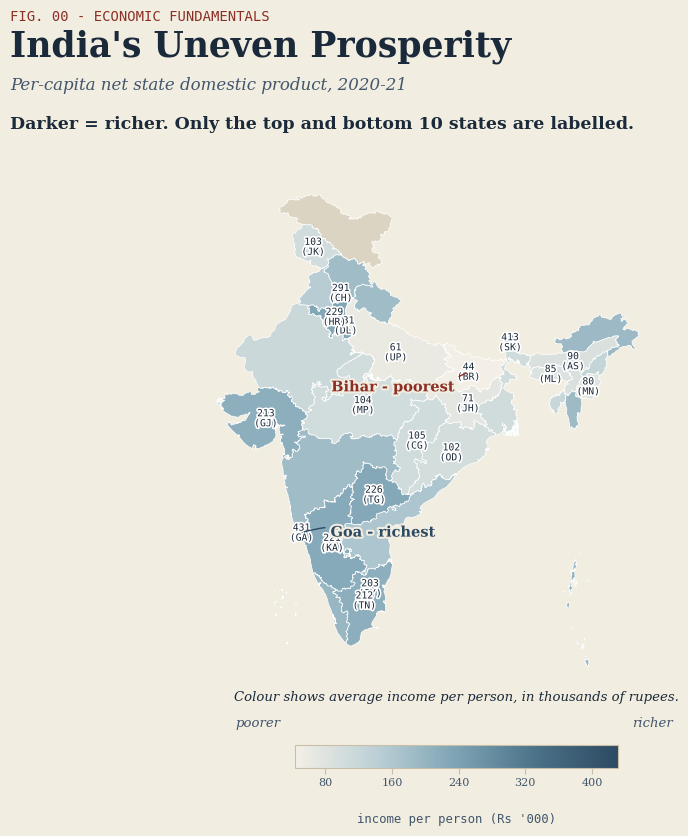

<Figure size 720x936 with 0 Axes>

In [22]:
col = "income_pc"
d = gdf.dropna(subset=[col]).copy(); d["income_k"] = d[col]/1000
gdf2 = gdf.copy(); gdf2["income_k"] = gdf2[col]/1000
vmin, vmax = d["income_k"].min(), d["income_k"].max()

# ---- MAP IMAGE ----
fig, ax = lahchen_base()
draw_choropleth(ax, gdf2, "income_k", ramp_cool, vmin, vmax)
label_extremes(ax, gdf2, "income_k", lambda v:f"{v:,.0f}", k=10)
title_block(fig, "FIG. 00 - ECONOMIC FUNDAMENTALS", "India's Uneven Prosperity",
            "Per-capita net state domestic product, 2020-21")
takeaway(fig, "Darker = richer. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp_cool, vmin, vmax, unit="income per person (Rs '000)",
                   low_label="poorer", high_label="richer",
                   note="Colour shows average income per person, in thousands of rupees.")
callout(ax, gdf2, "Goa", "Goa - richest", 2.0, 0.0, PLOT)
callout(ax, gdf2, "Bihar", "Bihar - poorest", -9.5, -1.0, OXBLOOD)
plt.savefig("fig0_prosperity_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

# ---- TABLE IMAGE ----
make_table_image(d, ["income_k"], ["Income/person"], ["Rs '000"],
                 [lambda v:f"{v:,.0f}"], "FIG. 00 - PROSPERITY: TOP & BOTTOM 10",
                 fname="fig0_prosperity_table.png")

### Figure 1 — The Burden of Child Stunting

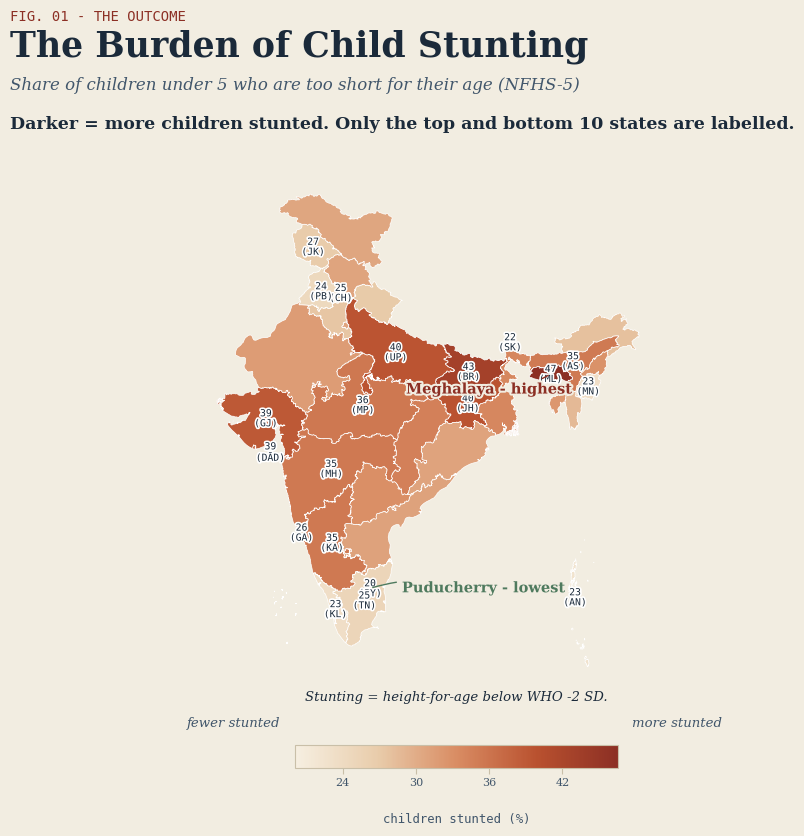

<Figure size 720x936 with 0 Axes>

In [23]:
col = "stunting_pct"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()

fig, ax = lahchen_base()
draw_choropleth(ax, gdf, col, ramp, vmin, vmax)
label_extremes(ax, gdf, "stunting_pct", lambda v:f"{v:.0f}", k=10)
title_block(fig, "FIG. 01 - THE OUTCOME", "The Burden of Child Stunting",
            "Share of children under 5 who are too short for their age (NFHS-5)")
takeaway(fig, "Darker = more children stunted. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp, vmin, vmax, unit="children stunted (%)",
                   low_label="fewer stunted", high_label="more stunted",
                   note="Stunting = height-for-age below WHO -2 SD.")
hi=d.nlargest(1,col).iloc[0]; lo=d.nsmallest(1,col).iloc[0]
callout(ax, gdf, hi["name"], f"{hi['name']} - highest", -10, -1, OXBLOOD)
callout(ax, gdf, lo["name"], f"{lo['name']} - lowest", 2.2, 0, GREEN)
plt.savefig("fig1_stunting_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

make_table_image(d, ["stunting_pct"], ["Stunting"], ["%"],
                 [lambda v:f"{v:.1f}"], "FIG. 01 - STUNTING: TOP & BOTTOM 10",
                 fname="fig1_stunting_table.png")

### Figure 2 — The Wealth Gap in Child Stunting

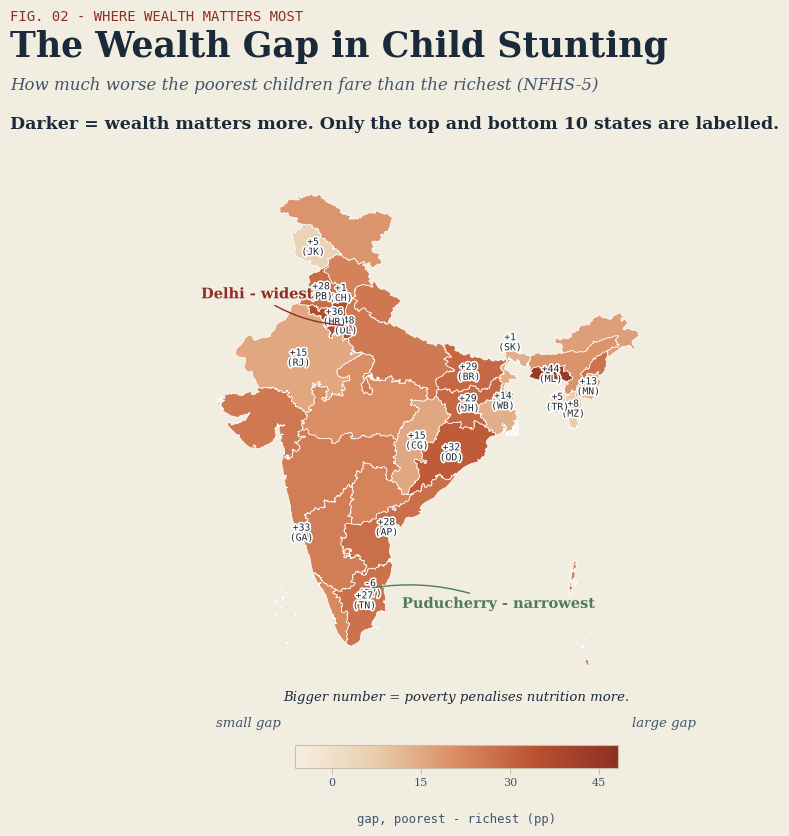

<Figure size 720x936 with 0 Axes>

In [24]:
col = "gap_pp"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()

fig, ax = lahchen_base()
draw_choropleth(ax, gdf, col, ramp, vmin, vmax)
label_extremes(ax, gdf, "gap_pp", lambda v:f"{v:+.0f}", k=10)
title_block(fig, "FIG. 02 - WHERE WEALTH MATTERS MOST", "The Wealth Gap in Child Stunting",
            "How much worse the poorest children fare than the richest (NFHS-5)")
takeaway(fig, "Darker = wealth matters more. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp, vmin, vmax, unit="gap, poorest - richest (pp)",
                   low_label="small gap", high_label="large gap",
                   note="Bigger number = poverty penalises nutrition more.")
hi=d.nlargest(1,col).iloc[0]; lo=d.nsmallest(1,col).iloc[0]
callout(ax, gdf, hi["name"], f"{hi['name']} - widest", -10, 2, OXBLOOD)
callout(ax, gdf, lo["name"], f"{lo['name']} - narrowest", 2.2, -1, GREEN)
plt.savefig("fig2_gap_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

make_table_image(d, ["gap_pp","poor_stunting_pct","rich_stunting_pct"],
                 ["Gap","Poorest","Richest"], ["pp","%","%"],
                 [lambda v:f"{v:+.1f}", lambda v:f"{v:.1f}", lambda v:f"{v:.1f}"],
                 "FIG. 02 - WEALTH GAP: TOP & BOTTOM 10", fname="fig2_gap_table.png")

### Figure 3 — Stunting Among the Poorest Children

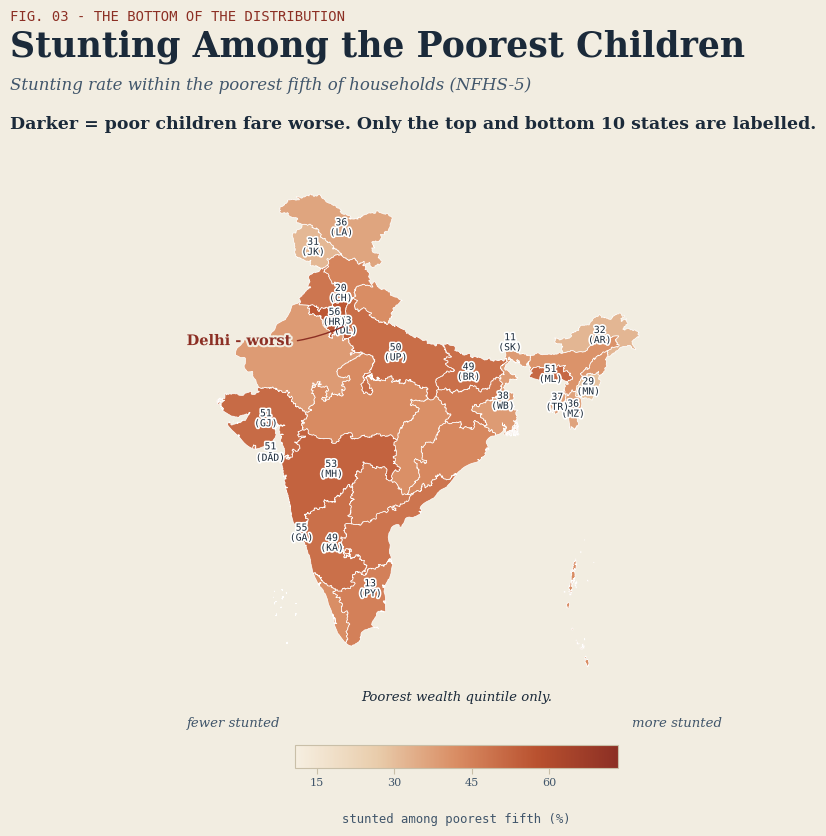

<Figure size 720x936 with 0 Axes>

In [25]:
col = "poor_stunting_pct"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()

fig, ax = lahchen_base()
draw_choropleth(ax, gdf, col, ramp, vmin, vmax)
label_extremes(ax, gdf, "poor_stunting_pct", lambda v:f"{v:.0f}", k=10)
title_block(fig, "FIG. 03 - THE BOTTOM OF THE DISTRIBUTION", "Stunting Among the Poorest Children",
            "Stunting rate within the poorest fifth of households (NFHS-5)")
takeaway(fig, "Darker = poor children fare worse. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp, vmin, vmax, unit="stunted among poorest fifth (%)",
                   low_label="fewer stunted", high_label="more stunted",
                   note="Poorest wealth quintile only.")
hi=d.nlargest(1,col).iloc[0]
callout(ax, gdf, hi["name"], f"{hi['name']} - worst", -11, -1, OXBLOOD)
plt.savefig("fig3_poor_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

make_table_image(d, ["poor_stunting_pct"], ["Stunting, poorest"], ["%"],
                 [lambda v:f"{v:.1f}"], "FIG. 03 - POOREST CHILDREN: TOP & BOTTOM 10",
                 fname="fig3_poor_table.png")

### Figure 4 — Stunting Among the Richest Children

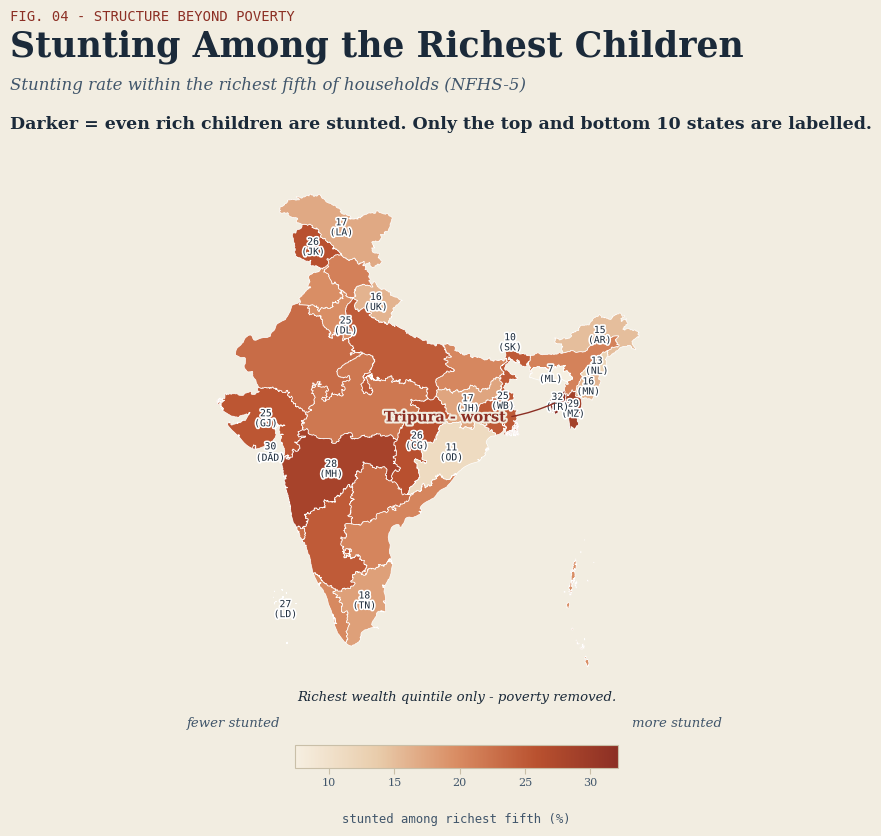

<Figure size 720x936 with 0 Axes>

In [26]:
col = "rich_stunting_pct"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()

fig, ax = lahchen_base()
draw_choropleth(ax, gdf, col, ramp, vmin, vmax)
label_extremes(ax, gdf, "rich_stunting_pct", lambda v:f"{v:.0f}", k=10)
title_block(fig, "FIG. 04 - STRUCTURE BEYOND POVERTY", "Stunting Among the Richest Children",
            "Stunting rate within the richest fifth of households (NFHS-5)")
takeaway(fig, "Darker = even rich children are stunted. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp, vmin, vmax, unit="stunted among richest fifth (%)",
                   low_label="fewer stunted", high_label="more stunted",
                   note="Richest wealth quintile only - poverty removed.")
hi=d.nlargest(1,col).iloc[0]
callout(ax, gdf, hi["name"], f"{hi['name']} - worst", -12, -1, OXBLOOD)
plt.savefig("fig4_rich_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

make_table_image(d, ["rich_stunting_pct"], ["Stunting, richest"], ["%"],
                 [lambda v:f"{v:.1f}"], "FIG. 04 - RICHEST CHILDREN: TOP & BOTTOM 10",
                 fname="fig4_rich_table.png")

### Figure 5 — The Absolute Burden\nRates flip to *counts* — the policy-relevant view. Big poor states dominate; tiny states recede.

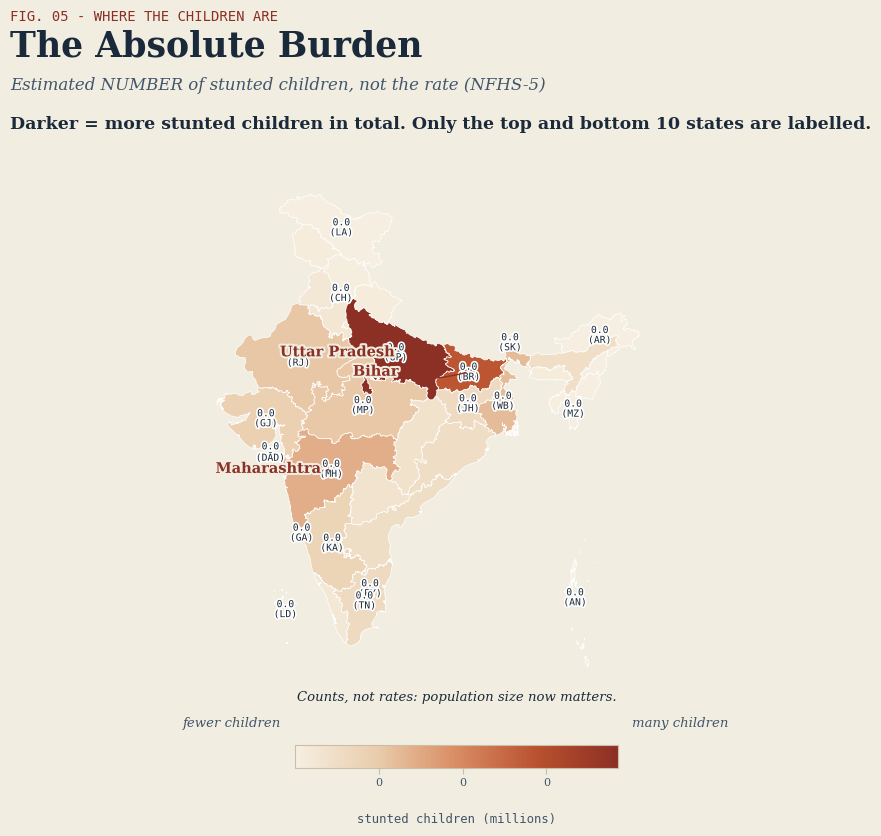

<Figure size 720x936 with 0 Axes>

In [27]:
col = "burden_weighted"
d = gdf.dropna(subset=[col]).copy(); d["burden_m"] = d[col]/1e6
gdf2 = gdf.copy(); gdf2["burden_m"] = gdf2[col]/1e6
vmin, vmax = d["burden_m"].min(), d["burden_m"].max()

fig, ax = lahchen_base()
draw_choropleth(ax, gdf2, "burden_m", ramp, vmin, vmax)
label_extremes(ax, gdf2, "burden_m", lambda v:f"{v:.1f}", k=10)
title_block(fig, "FIG. 05 - WHERE THE CHILDREN ARE", "The Absolute Burden",
            "Estimated NUMBER of stunted children, not the rate (NFHS-5)")
takeaway(fig, "Darker = more stunted children in total. Only the top and bottom 10 states are labelled.")
descriptive_legend(fig, ramp, vmin, vmax, unit="stunted children (millions)",
                   low_label="fewer children", high_label="many children",
                   note="Counts, not rates: population size now matters.")
for nm in d.nlargest(3, col)["name"]:
    callout(ax, gdf2, nm, nm, -8, 0, OXBLOOD)
plt.savefig("fig5_burden_map.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

make_table_image(d, ["burden_m"], ["Stunted children"], ["millions"],
                 [lambda v:f"{v:.2f}"], "FIG. 05 - ABSOLUTE BURDEN: TOP & BOTTOM 10",
                 fname="fig5_burden_table.png")

### Figure 6 — Prosperity vs Nutrition (summary figure)\nThe scatter where the real story lives: states above the fit line under-perform their income, those below out-perform it.

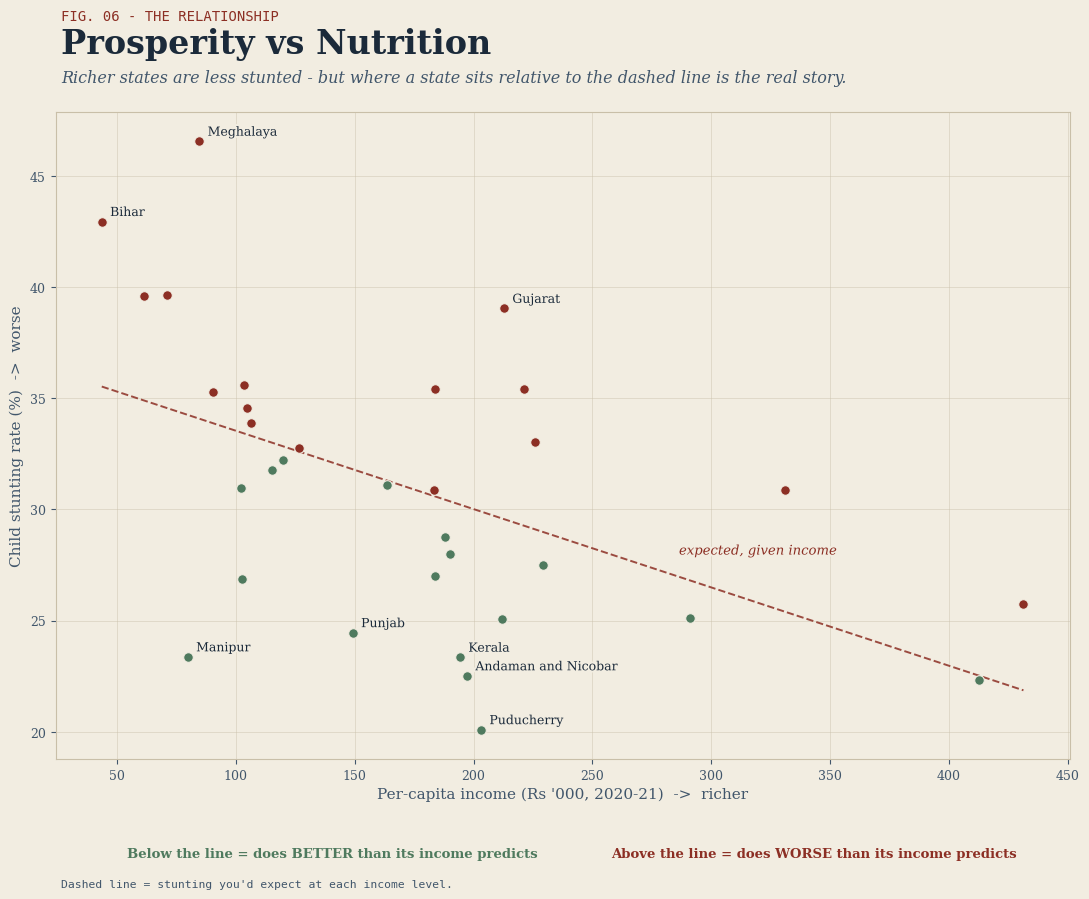

,State,Income (Rs '000),Stunting (%),Expected (%),Over/under (pp)
19,Manipur,79.8,23.4,34.3,-10.9
24,Puducherry,203.2,20.1,29.9,-9.8
0,Andaman and Nicobar,197.3,22.5,30.1,-7.6
25,Punjab,149.2,24.5,31.8,-7.3
16,Kerala,194.3,23.4,30.2,-6.9
34,Jammu and Kashmir,102.8,26.9,33.4,-6.6
28,Tamil Nadu,212.2,25.1,29.6,-4.5
31,Uttaranchal,184.0,27.0,30.6,-3.6
23,Orissa,102.2,31.0,33.5,-2.5
3,Arunachal Pradesh,190.2,28.0,30.4,-2.4


In [28]:
import numpy as np
d = gdf.dropna(subset=["income_pc","stunting_pct"]).copy()
d["income_k"] = d["income_pc"]/1000
x = d["income_pc"].values.astype(float); y = d["stunting_pct"].values.astype(float)
b1,b0 = np.polyfit(x,y,1); xfit=np.linspace(x.min(),x.max(),100); yfit=b0+b1*xfit
d["expected"] = b0 + b1*x
d["resid"] = y - d["expected"]

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
ax.grid(True, color=RULE, linewidth=0.5, alpha=0.6); ax.set_axisbelow(True)
ax.plot(xfit/1000, yfit, color=OXBLOOD, lw=1.4, ls="--", alpha=0.85, zorder=2)
ax.text((xfit/1000)[62], yfit[62]+1.0, "expected, given income",
        color=OXBLOOD, fontsize=9.5, style="italic", path_effects=HALO)

for _, r in d.iterrows():
    c = GREEN if r["resid"] < 0 else OXBLOOD
    ax.scatter(r["income_k"], r["stunting_pct"], s=48, color=c,
               edgecolor=PAPER, linewidth=0.8, zorder=3)
ds = d.reindex(d["resid"].abs().sort_values(ascending=False).index)
for _, r in ds.head(8).iterrows():
    ax.annotate(r["name"], (r["income_k"], r["stunting_pct"]),
                xytext=(6,4), textcoords="offset points", fontsize=9,
                color=INK, path_effects=HALO)

for s in ax.spines.values(): s.set_edgecolor(RULE)
ax.tick_params(colors=INKSOFT, labelsize=9)
ax.set_xlabel("Per-capita income (Rs '000, 2020-21)  ->  richer", fontsize=11, color=INKSOFT)
ax.set_ylabel("Child stunting rate (%)  ->  worse", fontsize=11, color=INKSOFT)

fig.text(0.06, 0.975, "FIG. 06 - THE RELATIONSHIP", family="monospace", fontsize=10, color=OXBLOOD)
fig.text(0.06, 0.938, "Prosperity vs Nutrition", fontsize=24, fontweight="bold", color=INK)
fig.text(0.06, 0.906, "Richer states are less stunted - but where a state sits relative to the dashed line is the real story.",
         fontsize=11.5, color=INKSOFT, style="italic")
fig.text(0.12, 0.045, "Below the line = does BETTER than its income predicts",
         fontsize=9.5, color=GREEN, fontweight="bold")
fig.text(0.56, 0.045, "Above the line = does WORSE than its income predicts",
         fontsize=9.5, color=OXBLOOD, fontweight="bold")
fig.text(0.06, 0.012, "Dashed line = stunting you'd expect at each income level.",
         family="monospace", fontsize=8.2, color=INKSOFT)

# data table for the scatter (income, stunting, expected, over/under)
tbl = d.copy()
tbl["over"] = np.where(tbl["resid"]<0, "better", "worse")
fig.text(0.06, 0.0, "", )  # spacer
plt.tight_layout(rect=[0,0.09,1,0.89])
plt.savefig("fig6_scatter.png", dpi=300, bbox_inches="tight", facecolor=PAPER)
plt.show()

# print the scatter's underlying table separately (clean console/DataFrame view)
scatter_table = (d[["name","income_k","stunting_pct","expected","resid"]]
                 .rename(columns={"name":"State","income_k":"Income (Rs '000)",
                                  "stunting_pct":"Stunting (%)","expected":"Expected (%)",
                                  "resid":"Over/under (pp)"})
                 .sort_values("Over/under (pp)").round(1))
scatter_table

---
**Done.** Six figures saved as `fig0…fig6 .png` at 300 dpi on Lahchen Maps paper.

Honest notes for the writeup:
- *Burden* (Fig 5) is a **weighted survey-count proxy**, not a population census of stunted children. To get true counts, multiply each state's stunting rate by its under-5 population from Census/projections.
- The Fig 6 fit is linear in income for legibility; a log-income fit usually fits better and is worth showing as a robustness version.
- All rates are survey-weighted; state estimates for very small states/UTs carry wider error bars — worth flagging before ranking them.